# CAD-Pattern-Detection Colab Runner

This notebook clones `garcia-ho/CAD-Pattern-Detection`, copies a CAD input image from Google Drive, and runs the repository's YOLO pattern detection command:

```bash
cd CAD_matching
python Pattern_match/main.py --input-cad Pattern_match/input_CAD --processed-dir Pattern_match/input_image --output Pattern_match/output_CAD
```

Default Drive input:
- `/content/drive/MyDrive/stone/test.jpg`

YOLO detection requires trained weights. Put `best.pt` in `/content/drive/MyDrive/stone/best.pt`, or edit `MODEL_PATH` below.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# System and Python dependencies for the Pattern_match pipeline.
!apt-get -qq update
!apt-get -qq install -y poppler-utils
!pip -q install numpy opencv-python pillow torch torchvision ultralytics supervision pymupdf pdf2image tqdm matplotlib pandas scikit-image

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [4]:
# Clone the upstream repository as CAD_matching, matching the README commands.
from pathlib import Path
import shutil

%cd /content
repo_clone_path = Path('/content/CAD_matching')
if repo_clone_path.exists():
    shutil.rmtree(repo_clone_path)
!git clone https://github.com/garcia-ho/CAD-Pattern-Detection.git CAD_matching
%cd /content/CAD_matching
!git rev-parse --short HEAD
!ls -la

/content
Cloning into 'CAD_matching'...
remote: Enumerating objects: 226, done.
remote: Counting objects: 100% (226/226), done.
remote: Compressing objects: 100% (172/172), done.
remote: Total 226 (delta 70), reused 177 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (226/226), 24.17 MiB | 27.50 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/CAD_matching
d98e00e
total 56
drwxr-xr-x 8 root root 4096 Jul  2 19:05 .
drwxr-xr-x 1 root root 4096 Jul  2 19:05 ..
drwxr-xr-x 8 root root 4096 Jul  2 19:05 .git
-rw-r--r-- 1 root root  569 Jul  2 19:05 .gitignore
drwxr-xr-x 2 root root 4096 Jul  2 19:05 logs
drwxr-xr-x 3 root root 4096 Jul  2 19:05 Pattern_match
drwxr-xr-x 2 root root 4096 Jul  2 19:05 __pycache__
-rw-r--r-- 1 root root 4849 Jul  2 19:05 README.md
drwxr-xr-x 2 root root 4096 Jul  2 19:05 readme_png
-rw-r--r-- 1 root root  619 Jul  2 19:05 requirements.txt
-rw-r--r-- 1 root root 6463 Jul  2 19:05 segment_cad.py
drwxr-xr-x 2 root root 4096 Jul  2 19:05 Strin

In [5]:
from pathlib import Path
import shutil

candidate_stone_dirs = [
    Path('/content/drive/MyDrive/stone'),
    Path('/content/drive/stone'),
]
STONE_DIR = next((path for path in candidate_stone_dirs if path.exists()), candidate_stone_dirs[0])

CAD_PATH = STONE_DIR / 'test.jpg'
REPO_DIR = Path('/content/CAD_matching')
INPUT_DIR = REPO_DIR / 'Pattern_match' / 'input_CAD'
PROCESSED_DIR = REPO_DIR / 'Pattern_match' / 'input_image'
OUTPUT_DIR = REPO_DIR / 'Pattern_match' / 'output_CAD'
REPORT_PATH = REPO_DIR / 'Pattern_match' / 'detection_report.csv'
DRIVE_OUTPUT_DIR = STONE_DIR / 'pattern_detection_output'

if not CAD_PATH.exists():
    raise FileNotFoundError(f'Missing CAD input image: {CAD_PATH}')

for directory in [INPUT_DIR, PROCESSED_DIR, OUTPUT_DIR, DRIVE_OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Keep the input folder clean so each run only processes the selected Drive image.
for existing in INPUT_DIR.iterdir():
    if existing.is_file():
        existing.unlink()

copied_input = INPUT_DIR / CAD_PATH.name
shutil.copy2(CAD_PATH, copied_input)

print('Drive stone dir:', STONE_DIR)
print('Copied input to:', copied_input)
print('Processed images:', PROCESSED_DIR)
print('Pattern output:', OUTPUT_DIR)
print('Report:', REPORT_PATH)

Drive stone dir: /content/drive/MyDrive/stone
Copied input to: /content/CAD_matching/Pattern_match/input_CAD/test.jpg
Processed images: /content/CAD_matching/Pattern_match/input_image
Pattern output: /content/CAD_matching/Pattern_match/output_CAD
Report: /content/CAD_matching/Pattern_match/detection_report.csv


In [ ]:
# Download YOLO weights into the cloned repo path expected by Pattern_match/main.py.
# yolov8x.pt is the small generic YOLOv8 model from Ultralytics on Hugging Face.
YOLO_MODEL_URL = 'https://huggingface.co/Ultralytics/YOLOv8/resolve/main/yolov8x.pt'
YOLO_MODEL_PATH = REPO_DIR / 'Pattern_match' / 'runs' / 'detect' / 'train' / 'weights' / 'best.pt'
YOLO_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
import os

if YOLO_MODEL_PATH.exists() and YOLO_MODEL_PATH.stat().st_size > 1_000_000:
    print('YOLO model already exists. Reloading from HF:', YOLO_MODEL_PATH)
    os.remove(YOLO_MODEL_PATH)

    print('Downloading YOLO model to:', YOLO_MODEL_PATH)
    !curl -L --fail --progress-bar -o "{YOLO_MODEL_PATH}" "{YOLO_MODEL_URL}"

print('YOLO model size MB:', round(YOLO_MODEL_PATH.stat().st_size / 1024 / 1024, 2))

YOLO model already exists: /content/CAD_matching/Pattern_match/runs/detect/train/weights/best.pt
YOLO model size MB: 6.23


In [7]:
# Find trained YOLO weights. Edit MODEL_PATH manually if your weights are elsewhere.
from pathlib import Path

MODEL_PATH = None
model_candidates = [
    STONE_DIR / 'best.pt',
    STONE_DIR / 'runs' / 'detect' / 'train' / 'weights' / 'best.pt',
    REPO_DIR / 'Pattern_match' / 'runs' / 'detect' / 'train' / 'weights' / 'best.pt',
    REPO_DIR / 'runs' / 'detect' / 'train' / 'weights' / 'best.pt',
]

for candidate in model_candidates:
    if candidate.exists():
        MODEL_PATH = candidate
        break

if MODEL_PATH is None:
    discovered = sorted(STONE_DIR.rglob('*.pt')) + sorted(REPO_DIR.rglob('*.pt'))
    if discovered:
        MODEL_PATH = discovered[0]

if MODEL_PATH is None:
    raise FileNotFoundError(
        'No YOLO model weights found. Upload best.pt to '
        f'{STONE_DIR / "best.pt"} or set MODEL_PATH manually in this cell.'
    )

print('Using YOLO model:', MODEL_PATH)

Using YOLO model: /content/CAD_matching/Pattern_match/runs/detect/train/weights/best.pt


In [8]:
# Run pattern detection using the repository CLI.
# This is the README command plus --model, because the cloned repo does not include trained weights.
%cd /content/CAD_matching
!python Pattern_match/main.py \
  --input-cad Pattern_match/input_CAD \
  --processed-dir Pattern_match/input_image \
  --output Pattern_match/output_CAD \
  --model "{MODEL_PATH}" \
  --report Pattern_match/detection_report.csv

/content/CAD_matching

=== Step 1: Preprocessing CAD Drawings ===
Found 1 files in Pattern_match/input_CAD
Processing files sequentially...
Processing files:   0% 0/1 [00:00<?, ?it/s]Processing large image of size 10525x4963 using tiling
Splitting into 6 tiles (2x3)

Processing tiles:   0% 0/6 [00:00<?, ?it/s]
Processing tiles:  17% 1/6 [00:00<00:02,  1.69it/s]
Processing tiles:  33% 2/6 [00:00<00:01,  2.23it/s]
Processing tiles:  50% 3/6 [00:01<00:00,  3.05it/s]
Processing tiles: 100% 6/6 [00:01<00:00,  4.72it/s]
Processing files: 100% 1/1 [00:03<00:00,  3.41s/it]
Processed 1 images from 1 input files
Preprocessed 1 images

=== Step 2: Running YOLO Detection ===
Loading model from /content/CAD_matching/Pattern_match/runs/detect/train/weights/best.pt
Found 1 images in Pattern_match/input_image
Processing images:   0% 0/1 [00:00<?, ?it/s]Created 72 segments

Processing segments:   0% 0/72 [00:00<?, ?it/s]
Processing segments:   1% 1/72 [00:01<02:21,  1.99s/it]
Processing segments:  14% 

In [9]:
# Copy results back to Google Drive.
import shutil
from pathlib import Path

DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if OUTPUT_DIR.exists():
    for path in OUTPUT_DIR.iterdir():
        destination = DRIVE_OUTPUT_DIR / path.name
        if path.is_dir():
            if destination.exists():
                shutil.rmtree(destination)
            shutil.copytree(path, destination)
        else:
            shutil.copy2(path, destination)

if REPORT_PATH.exists():
    shutil.copy2(REPORT_PATH, DRIVE_OUTPUT_DIR / REPORT_PATH.name)

print('Copied detection outputs to:', DRIVE_OUTPUT_DIR)
!find "{DRIVE_OUTPUT_DIR}" -maxdepth 2 -type f | sort | head -50

Copied detection outputs to: /content/drive/MyDrive/stone/pattern_detection_output
/content/drive/MyDrive/stone/pattern_detection_output/detection_report.csv
/content/drive/MyDrive/stone/pattern_detection_output/test.png


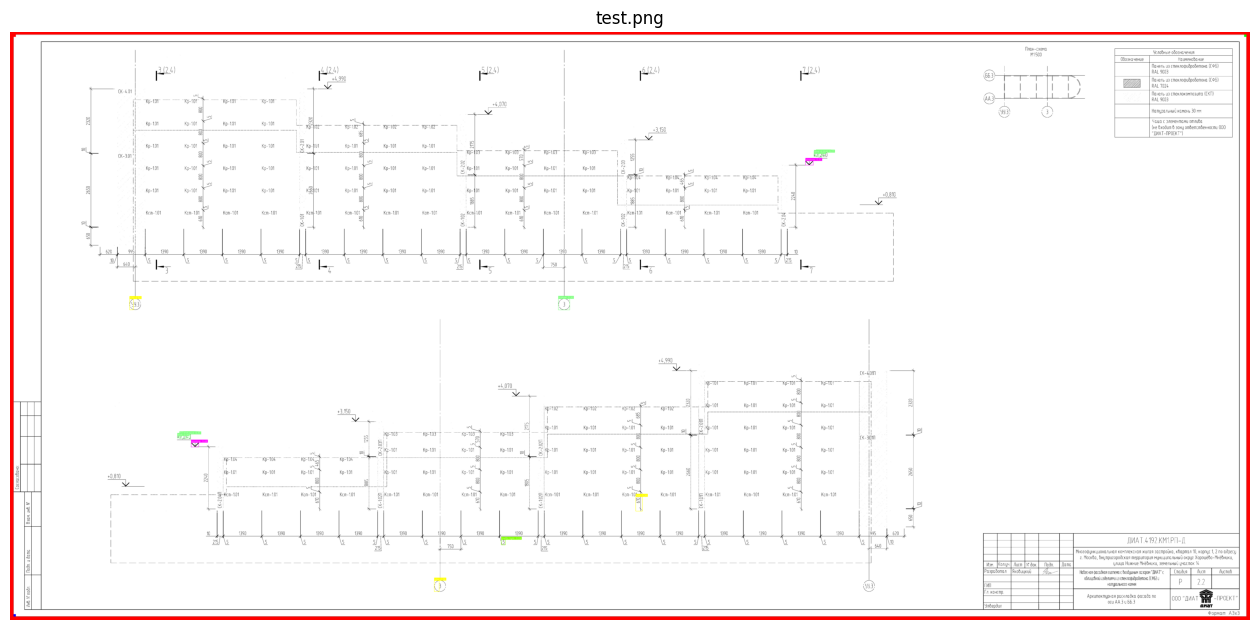

In [10]:
# Preview annotated outputs in Colab.
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

image_paths = []
for suffix in ('*.png', '*.jpg', '*.jpeg'):
    image_paths.extend(sorted(OUTPUT_DIR.glob(suffix)))

if not image_paths:
    print('No annotated image outputs found in', OUTPUT_DIR)
else:
    for image_path in image_paths[:6]:
        image = Image.open(image_path)
        plt.figure(figsize=(16, 10))
        plt.imshow(image)
        plt.axis('off')
        plt.title(image_path.name)
        plt.show()

In [ ]:
# Optional: zip outputs for download from the Colab file browser.
%cd /content/CAD_matching/Pattern_match
!zip -q -r /content/pattern_detection_output.zip output_CAD detection_report.csv input_image
print('/content/pattern_detection_output.zip')